# Número de especies que cuentan con un Plan de Recuperación, Conservación y Gestión de Especies (RECOGE).

Este indicador nacional cuantifica el número absoluto de taxones que se encuentran amparados formalmente bajo un Plan de Recuperación, Conservación y Gestión de Especies (RECOGE). Su objetivo es monitorear el avance hacia la Meta Nacional I.6, la cual establece que al año 2030 se deben aumentar en al menos un 50% las especies protegidas bajo este instrumento, utilizando como línea base el año 2023. Los planes RECOGE constituyen el principal mecanismo operativo del Estado para priorizar, estructurar y coordinar intersectorialmente acciones concretas y medibles destinadas a evitar la extinción de especies amenazadas.
El acceso a la planilla de datos del indicador se encuentra disponible [aquí](https://docs.google.com/spreadsheets/d/1Sa49WXmJs6wXZBSG-jcHLAid_UOg7G9t/edit?usp=drive_link&ouid=103438392959464183742&rtpof=true&sd=true).

## Metodología de Cálculo

El cálculo se realiza mediante la sumatoria del número total de especies incluidas en los planes RECOGE que han sido aprobados y publicados en el Diario Oficial. El indicador contabiliza tanto a las especies que cuentan con planes individuales ("monoespecie") como a aquellas integradas en planes colectivos ("multiespecie"). El nivel de progreso hacia la meta se determina calculando la brecha entre el número de especies acumuladas al año base (2023) y el objetivo proyectado para 2030.

# Capa 1: Observación y recolección
### Fuentes de Datos Utilizadas
La fuente de información oficial para este indicador es el Sistema de Información de Biodiversidad (SIMBIO) administrado por el Ministerio del Medio Ambiente, el cual cuenta con un "Módulo de Planes RECOGE". Esta plataforma centraliza los expedientes, resoluciones de aprobación, y los listados taxonómicos exactos de las especies que integran cada instrumento.


In [1]:
import requests
import pandas as pd
from io import BytesIO
import matplotlib.pyplot as plt

In [2]:
# URL oficial de descarga del Catálogo Extendido RECOGE (SIMBIO)
URL_EXCEL = "https://simbio.mma.gob.cl/PlanesRecoge/GetExcelExtendido"

print("Descargando archivo Excel desde SIMBIO...")

response = requests.get(URL_EXCEL)

# Verificar estado de descarga
if response.status_code != 200:
    raise Exception(
        f"Error al descargar el archivo. Código HTTP: {response.status_code}"
    )

print("Descarga completada correctamente ✅")

excel_data = BytesIO(response.content)

Descargando archivo Excel desde SIMBIO...
Descarga completada correctamente ✅


In [3]:
decretos = pd.read_excel(excel_data, sheet_name="Decretos")
decretos["Fecha publicación"] = pd.to_datetime(decretos["Fecha publicación"], format="%d/%m/%Y")
decretos["Año"] = decretos["Fecha publicación"].dt.year
plan_simple = pd.read_excel(excel_data, sheet_name="Especies tipo plan simple")
plan_multiple = pd.read_excel(excel_data, sheet_name="Especiestipo plan múltiple")

print("\n✅ Columnas - Decretos:")
print(decretos.columns)

print("\n✅ Columnas - Especies tipo plan simple:")
print(plan_simple.columns)

print("\n✅ Columnas - Especies tipo plan múltiple:")
print(plan_multiple.columns)

print("\nPrimeras filas - Decretos:")
display(decretos.head())

print("\nPrimeras filas - Plan simple:")
display(plan_simple.head())

print("\nPrimeras filas - Plan múltiple:")
display(plan_multiple.head())


✅ Columnas - Decretos:
Index(['ID plan', 'N° Decreto', 'Nombre', 'Fecha promulgación',
       'Fecha publicación', 'URL', 'Año'],
      dtype='str')

✅ Columnas - Especies tipo plan simple:
Index(['ID plan', 'Nombre común', 'Nombre científico',
       'Estado de conservación', 'Antecedentes de la especie'],
      dtype='str')

✅ Columnas - Especies tipo plan múltiple:
Index(['ID plan', 'Reino', 'Phyllum', 'Clase', 'Orden', 'Familia',
       'NombreComun', 'NombreCientifico', 'EstadoConservacion',
       'UrlFichaInventario'],
      dtype='str')

Primeras filas - Decretos:


,ID plan,N° Decreto,Nombre,Fecha promulgación,Fecha publicación,URL,Año
0,RECOGE0001,12345,Decreto Test,01/09/2020,2020-09-11,https://www.soporta.cl,2020
1,RECOGE0001,NS34,Otro Decreto,07/05/2020,2020-06-01,https://www.google.com,2020
2,RECOGE0001,Por definir,Por definir,02/01/2020,2020-01-01,https://www.google.cl,2020
3,RECOGE0001,Por definir,Por definir,01/01/2019,2019-01-01,por definir,2019
4,RECOGE0001,Por definir,Por definir,01/01/2021,2021-01-01,Por definir,2021



Primeras filas - Plan simple:


,ID plan,Nombre común,Nombre científico,Estado de conservación,Antecedentes de la especie
0,RECOGE0002,Ruil,Nothofagus alessandrii,En Peligro (EN),El ruil (Nothofagus alessandrii) es un árbol e...
1,RECOGE0003,Lucumillo,Myrcianthes coquimbensis,En Peligro (EN),El lucumillo (Myrcianthes coquimbensis) es un ...
2,RECOGE0004,Garra de león,Leontochir ovallei,En Peligro (EN),Bomarea ovallei es una especie endémica de la ...
3,RECOGE0005,Chinchilla de cola corta,"Chinchilla chinchilla (Lichtenstein, 1829)",En peligro crítico (CR),La taxonomía del género Chinchilla ha dado pie...
4,RECOGE0006,Huemul,Hippocamelus bisulcus (Molina 1782),En Peligro (EN),El Plan describe al huemul como un ciervo de t...



Primeras filas - Plan múltiple:


,ID plan,Reino,Phyllum,Clase,Orden,Familia,NombreComun,NombreCientifico,EstadoConservacion,UrlFichaInventario
0,RECOGE0001,Plantae,Magnoliophyta,Magnoliopsida,Fabales,Fabaceae,.,Adesmia micrantha,VU,https://simbio.mma.gob.cl/Especies/Details/13237
1,RECOGE0001,Plantae,Pteridophyta,Polypodiopsida,Polypodiales,Pteridaceae,Palito negro,Adiantum chilense,LC,https://simbio.mma.gob.cl/Especies/Details/15749
2,RECOGE0001,Plantae,Magnoliophyta,Liliopsida,Liliales,Alstroemeriaceae,Lirio,Alstroemeria graminea,VU,https://simbio.mma.gob.cl/Especies/Details/6925
3,RECOGE0001,Plantae,Magnoliophyta,Liliopsida,Liliales,Alstroemeriaceae,Lirio,Alstroemeria lutea,EN,https://simbio.mma.gob.cl/Especies/Details/6934
4,RECOGE0001,Plantae,Pteridophyta,Polypodiopsida,Polypodiales,Aspleniaceae,Helecho,Asplenium peruvianum,CR,https://simbio.mma.gob.cl/Especies/Details/17728


In [4]:
# Obtener rango de fechas

year_min = decretos["Año"].min()
year_max = decretos["Año"].max()

years = list(range(year_min, year_max + 1))
years

[2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025]

# Capa 2: Análisis y síntesis

Planes RECOGE por año

In [5]:
plan_year_dict = decretos.groupby("ID plan")["Año"].min().to_dict()
plan_year_dict

{'RECOGE0001': 2018,
 'RECOGE0002': 2018,
 'RECOGE0003': 2018,
 'RECOGE0004': 2021,
 'RECOGE0005': 2021,
 'RECOGE0006': 2022,
 'RECOGE0007': 2022,
 'RECOGE0008 ': 2021,
 'RECOGE0009': 2022,
 'RECOGE0010': 2022,
 'RECOGE0011': 2022,
 'RECOGE0012 ': 2022,
 'RECOGE0013': 2023,
 'RECOGE0014': 2024,
 'RECOGE0015': 2025,
 'RECOGE0016': 2025,
 'RECOGE0017': 2025}

In [6]:
plan_year_data = pd.DataFrame(list(plan_year_dict.items()), columns=["ID plan", "Año"])
plan_year_data

,ID plan,Año
0,RECOGE0001,2018
1,RECOGE0002,2018
2,RECOGE0003,2018
3,RECOGE0004,2021
4,RECOGE0005,2021
5,RECOGE0006,2022
6,RECOGE0007,2022
7,RECOGE0008,2021
8,RECOGE0009,2022
9,RECOGE0010,2022


In [7]:
# Definir salida por año

data = pd.DataFrame(years, columns=["Año"])
data

,Año
0,2018
1,2019
2,2020
3,2021
4,2022
5,2023
6,2024
7,2025


In [8]:
# Obtener Planes por año

data["Nuevos Planes RECOGE"] = 0
for year in years:
    year_index = data[data["Año"] == year].index[0]
    data.loc[year_index, "Nuevos Planes RECOGE"] = (plan_year_data["Año"] == year).sum()
data

,Año,Nuevos Planes RECOGE
0,2018,3
1,2019,0
2,2020,0
3,2021,3
4,2022,6
5,2023,1
6,2024,1
7,2025,3


## Resultados 

La evaluación histórica e interanual de este indicador arroja los siguientes resultados estadísticos:
- Universo Histórico: Desde el inicio de la implementación de este instrumento (2018) a la fecha, se han oficializado 16 planes que amparan a un total de 116 especies en categoría de amenaza.
- Línea Base y Avance Reciente (2023-2025): Al comenzar el periodo de evaluación de la meta en 2023, el indicador registraba un acumulado de 13 planes cubriendo a 113 especies (volumen histórico alcanzado principalmente gracias a la dictación de planes multiespecie en 2018 y 2022). Posteriormente, durante los años 2024 y 2025, el avance cuantitativo ha sido muy limitado, sumándose solo 3 planes simples que incorporaron 3 nuevas especies al indicador.
- Nivel de Cumplimiento: Considerando la línea base de 113 especies, la meta exige alcanzar un total de 173 taxa amparados al año 2030 (es decir, sumar 60 nuevas especies). Con las 3 especies incorporadas recientemente, el estado de avance actual para el cumplimiento de la meta alcanza un 5,2%.

In [9]:
data["Especies en planes simples"] = 0
for year in years:
    year_index = data[data["Año"] == year].index[0]
    selection = plan_simple[plan_simple["ID plan"].isin(plan_year_data[plan_year_data["Año"] == year]["ID plan"])]
    print("""
        Especies en año {}:
        \tTodas: {}
        \tÚnicas: {}
    """.format(
        year, list(selection["Nombre científico"]), list(selection["Nombre científico"].drop_duplicates())
    ))
    data.loc[year_index, "Especies en planes simples"] = len(selection["Nombre científico"].drop_duplicates())
data


        Especies en año 2018:
        	Todas: ['Nothofagus alessandrii', 'Myrcianthes coquimbensis']
        	Únicas: ['Nothofagus alessandrii', 'Myrcianthes coquimbensis']
    

        Especies en año 2019:
        	Todas: []
        	Únicas: []
    

        Especies en año 2020:
        	Todas: []
        	Únicas: []
    

        Especies en año 2021:
        	Todas: ['Leontochir ovallei', 'Chinchilla chinchilla (Lichtenstein, 1829)', 'Chloephaga rubidiceps']
        	Únicas: ['Leontochir ovallei', 'Chinchilla chinchilla (Lichtenstein, 1829)', 'Chloephaga rubidiceps']
    

        Especies en año 2022:
        	Todas: ['Hippocamelus bisulcus (Molina 1782)', 'Ardenna creatopus', 'Eulidia yarrellii']
        	Únicas: ['Hippocamelus bisulcus (Molina 1782)', 'Ardenna creatopus', 'Eulidia yarrellii']
    

        Especies en año 2023:
        	Todas: ['Gomortega keule']
        	Únicas: ['Gomortega keule']
    

        Especies en año 2024:
        	Todas: ['Spheniscus humboldti']


,Año,Nuevos Planes RECOGE,Especies en planes simples
0,2018,3,2
1,2019,0,0
2,2020,0,0
3,2021,3,3
4,2022,6,3
5,2023,1,1
6,2024,1,1
7,2025,3,3


In [13]:
data["Especies en planes múltiples"] = 0
for year in years:
    year_index = data[data["Año"] == year].index[0]
    selection = plan_multiple[plan_multiple["ID plan"].isin(plan_year_data[plan_year_data["Año"] == year]["ID plan"])]
    print("""
        Especies en año {}:
        \tTodas: {}
        \tÚnicas: {}
    """.format(
        year, list(selection["NombreCientifico"]), list(selection["NombreCientifico"].drop_duplicates())
    ))
    data.loc[year_index, "Especies en planes múltiples"] = len(selection["NombreCientifico"].drop_duplicates())
data


        Especies en año 2018:
        	Todas: ['Adesmia micrantha', 'Adiantum chilense', 'Alstroemeria graminea', 'Alstroemeria lutea', 'Asplenium peruvianum', 'Asteriscium vidalii', 'Atriplex taltalensis', 'Berberis litoralis', 'Bipinnula taltalensis', 'Calceolaria paposana', 'Cheilanthes bonariensis', 'Cheilanthes mollis', 'Cistanthe cachinalensis', 'Conanthera campanulata', 'Copiapoa ahremephiana', 'Copiapoa aphanes', 'Copiapoa boliviana', 'Copiapoa cinerascens', 'Copiapoa cinerea', 'Copiapoa grandiflora', 'Copiapoa humilis', 'Copiapoa hypogaea', 'Copiapoa krainziana', 'Copiapoa laui', 'Copiapoa longistaminea', 'Copiapoa marginata', 'Copiapoa montana', 'Copiapoa rupestris', 'Copiapoa serpentisulcata', 'Copiapoa solaris', 'Copiapoa taltalensis', 'Croton chilensis', 'Cumulopuntia sphaerica', 'Cylindropuntia tunicata', 'Cystopteris apiiformes (antes Cystopteris fragilis)', 'Dalea azurea', 'Deuterocohnia chrysantha', 'Dicliptera paposana', 'Echinopsis glauca', 'Equisetum giganteum', 'E

,Año,Nuevos Planes RECOGE,Especies en planes simples,Especies en planes múltiples,Especies totales (simple+múltiple),Acumulado planes,Acumulado especies (simple+múltiple)
0,2018,3,2,92,94,3,94
1,2019,0,0,0,0,3,94
2,2020,0,0,0,0,3,94
3,2021,3,3,0,3,6,97
4,2022,6,3,12,15,12,112
5,2023,1,1,0,1,13,113
6,2024,1,1,0,1,14,114
7,2025,3,3,0,3,17,117


In [15]:
data["Especies totales (simple+múltiple)"] = data["Especies en planes simples"] + data["Especies en planes múltiples"]
data["Acumulado planes"] = data["Nuevos Planes RECOGE"].cumsum()
data["Acumulado especies (simple+múltiple)"] = data["Especies totales (simple+múltiple)"].cumsum()
data.to_csv("data/recoge.csv", index=False, header=True)
data

,Año,Nuevos Planes RECOGE,Especies en planes simples,Especies en planes múltiples,Especies totales (simple+múltiple),Acumulado planes,Acumulado especies (simple+múltiple)
0,2018,3,2,92,94,3,94
1,2019,0,0,0,0,3,94
2,2020,0,0,0,0,3,94
3,2021,3,3,0,3,6,97
4,2022,6,3,12,15,12,112
5,2023,1,1,0,1,13,113
6,2024,1,1,0,1,14,114
7,2025,3,3,0,3,17,117


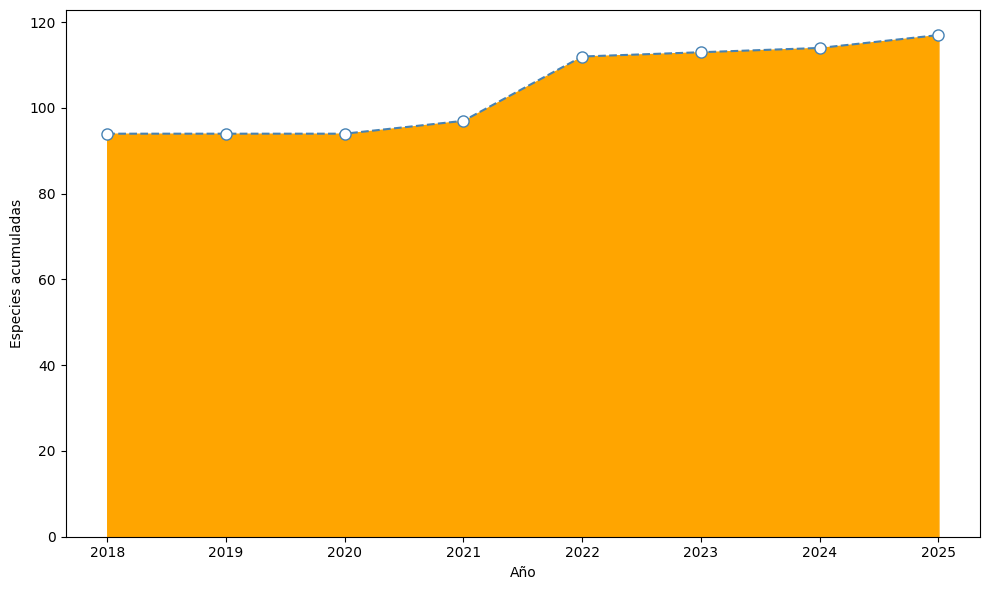

In [16]:
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(
    data["Año"], data["Acumulado especies (simple+múltiple)"],
    marker='o', linestyle='--', color='steelblue',
    markerfacecolor='white', markersize=8
)
ax.stackplot(data["Año"], data["Acumulado especies (simple+múltiple)"], color='orange')
ax.set_xlabel("Año")
ax.set_ylabel("Especies acumuladas")
fig.tight_layout()
fig.savefig("acumulado.png")

In [ ]:
## Observaciones
El indicador cuenta con un mecanismo de verificación trazable gracias al módulo específico de planes RECOGE en la plataforma SIMBIO, el cual centraliza la información y facilita el cálculo automatizado de esta métrica. Desde una perspectiva metodológica, es importante observar que el indicador contabiliza a todas las especies con el mismo peso estadístico, ya sea en planes individuales o multiespecie. Esto puede generar variaciones interanuales significativas (como los saltos cuantitativos de 2018 y 2022) que responden a la agrupación administrativa de taxones en un solo instrumento normativo.


In [38]:
import pandas as pd
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# =========================================
# Datos ya construidos como en tu script
# df_base, resumen, anios
# =========================================

# número máximo de filas para homogenizar tablas
max_rows = max(
    max(len(x) for x in resumen["Especies"]),
    1
)

def tabla_especies(anio):
    especies = (
        resumen.loc[
            resumen["Año"]==anio,
            "Especies"
        ].iloc[0]
    )

    especies = sorted(especies)

    # rellenar para mismo largo
    especies = especies + [""]*(max_rows-len(especies))

    return especies


# =========================================
# Figura
# =========================================
fig = make_subplots(
    rows=2,
    cols=1,
    specs=[
      [{"type":"xy"}],
      [{"type":"table"}]
    ],
    row_heights=[0.42,0.58],
    vertical_spacing=0.08,
    subplot_titles=(
      "Especies incorporadas por año en planes RECOGE",
      f"Listado de especies incorporadas ({anios[0]})"
    )
)

# -----------------------------------------
# Panel superior
# -----------------------------------------
fig.add_trace(
    go.Bar(
        x=resumen["Año"],
        y=resumen["n_especies_agregadas"],
        text=resumen["n_especies_agregadas"],
        textposition="outside",
        name="Especies agregadas",
        hovertemplate=
        "<b>Año:</b> %{x}<br>"+
        "<b>Especies:</b> %{y}<extra></extra>"
    ),
    row=1,col=1
)

fig.add_trace(
    go.Scatter(
        x=resumen["Año"],
        y=resumen["acumulado"],
        mode="lines+markers",
        name="Acumulado",
        hovertemplate=
        "<b>Año:</b> %{x}<br>"+
        "<b>Acumulado:</b> %{y}<extra></extra>"
    ),
    row=1,col=1
)

# -----------------------------------------
# Tabla por año
# -----------------------------------------
for i,anio in enumerate(anios):

    especies = tabla_especies(anio)

    fig.add_trace(
        go.Table(
            visible=(i==0),
            header=dict(
                values=[
                    f"Especies incorporadas ({anio})"
                ],
                align="left"
            ),
            cells=dict(
                values=[especies],
                align="left",
                height=24
            )
        ),
        row=2,col=1
    )

# =========================================
# Botones
# =========================================
n_static=2
botones=[]

for i,anio in enumerate(anios):

    visibles=(
      [True]*n_static +
      [False]*len(anios)
    )

    visibles[n_static+i]=True

    n_sp=int(
      resumen.loc[
       resumen["Año"]==anio,
       "n_especies_agregadas"
      ].iloc[0]
    )

    botones.append(
      dict(
       label=str(anio),
       method="update",
       args=[
        {"visible":visibles},
        {
        #  "annotations":[
        #   dict(
        #    x=0,
        #    y=0.50,
        #    xref="paper",
        #    yref="paper",
        #    text=
        #    f"Especies incorporadas en {anio}: {n_sp}",
        #    showarrow=False,
        #    xanchor="left"
        #   )
        #  ],
         "shapes":[
          dict(
           type="line",
           x0=anio,
           x1=anio,
           y0=0,
           y1=max(
             resumen["n_especies_agregadas"]
           )*1.1,
           xref="x1",
           yref="y1",
           line=dict(
            color="black",
            dash="dot",
            width=2
           )
          )
         ]
        }
       ]
      )
    )

# =========================================
# Layout
# =========================================
anio0=anios[0]
n0=int(
 resumen.loc[
  resumen["Año"]==anio0,
  "n_especies_agregadas"
 ].iloc[0]
)

fig.update_layout(
    template="plotly_white",
    autosize=True,
    height=950,
    margin=dict(
      l=30,r=20,t=110,b=30
    ),
    hovermode="x unified",

    xaxis=dict(
      title="Año",
      tickmode="array",
      tickvals=anios
    ),

    yaxis=dict(
      title="Número de especies"
    ),

    updatemenus=[
      dict(
       type="buttons",
       direction="right",
       x=0.5,
       y=1.15,
       xanchor="center",
       showactive=True,
       font=dict(size=10),
       buttons=botones
      )
    ],

    # annotations=[
    #   dict(
    #    x=0,
    #    y=0.50,
    #    xref="paper",
    #    yref="paper",
    #    showarrow=False,
    #    xanchor="left"
    #   )
    # ],

    shapes=[
      dict(
       type="line",
       x0=anio0,
       x1=anio0,
       y0=0,
       y1=max(
         resumen["n_especies_agregadas"]
       )*1.1,
       xref="x1",
       yref="y1",
       line=dict(
         color="black",
         dash="dot",
         width=2
       )
      )
    ]
)

fig.show(config={"responsive":True})